<a href="https://colab.research.google.com/github/Srikara2005/Text-Classification/blob/main/TextClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing packages
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [ ]:
#Load IMDB Dataset
train_data, val_data, test_data = tfds.load(
    "imdb_reviews",
    split=("train[:60%]", "train[60%:]", "test"),
    as_supervised=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.CV1G3T_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.CV1G3T_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.CV1G3T_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [ ]:
#Text Vectorization
max_tokens = 10000
sequence_length = 250

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=sequence_length
)

In [ ]:
# Fit vectorizer on training data
vectorizer.adapt(train_data.map(lambda x, y: x))

In [ ]:
#Build model
model = tf.keras.Sequential([
    vectorizer,
    tf.keras.layers.Embedding(input_dim=10000, output_dim=32),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
#Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train model
history = model.fit(
    train_data.shuffle(10000).batch(512),
    epochs=15,
    validation_data=val_data.batch(512)
)

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5371 - loss: 0.6909 - val_accuracy: 0.6675 - val_loss: 0.6394
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.6612 - loss: 0.6442 - val_accuracy: 0.7757 - val_loss: 0.5163
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8147 - loss: 0.4461 - val_accuracy: 0.8249 - val_loss: 0.4042
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8856 - loss: 0.2990 - val_accuracy: 0.8561 - val_loss: 0.3541
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9245 - loss: 0.2123 - val_accuracy: 0.8594 - val_loss: 0.3548
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.9312 - loss: 0.1929 - val_accuracy: 0.8533 - val_loss: 0.3914
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9499 - loss: 0.1504 - val_accuracy: 0.8568 - val_loss: 0.3892
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9642 - loss: 0.1137 - val_accuracy: 0.8433 - val_loss:

In [ ]:
#Evaluation on test data
results = model.evaluate(test_data.batch(512))
print(f"\nTest Loss: {results[0]:.4f}, Test Accuracy: {results[1]*100:.2f}%")

49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 378ms/step - accuracy: 0.8280 - loss: 0.6830

Test Loss: 0.6896, Test Accuracy: 82.53%


In [ ]:
#Prediction on new text
examples = [
    "The movie was amazing! I really loved it.",
    "Worst movie ever. Waste of time.",
    "It is a complete waste of time.",
    "It is a very good movie. It is an entertainer."
]
examples_dataset = tf.data.Dataset.from_tensor_slices(examples).batch(2)

predictions = model.predict(examples_dataset)

for review, score in zip(examples, predictions):
    print(f"Review: {review}")
    print(f"Sentiment score: {score[0]:.3f} ({'Positive' if score[0] > 0.1 else 'Negative'})\n")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 
Review: The movie was amazing! I really loved it.
Sentiment score: 0.924 (Positive)

Review: Worst movie ever. Waste of time.
Sentiment score: 0.004 (Negative)

Review: It is a complete waste of time.
Sentiment score: 0.073 (Negative)

Review: It is a very good movie. It is an entertainer.
Sentiment score: 0.784 (Positive)



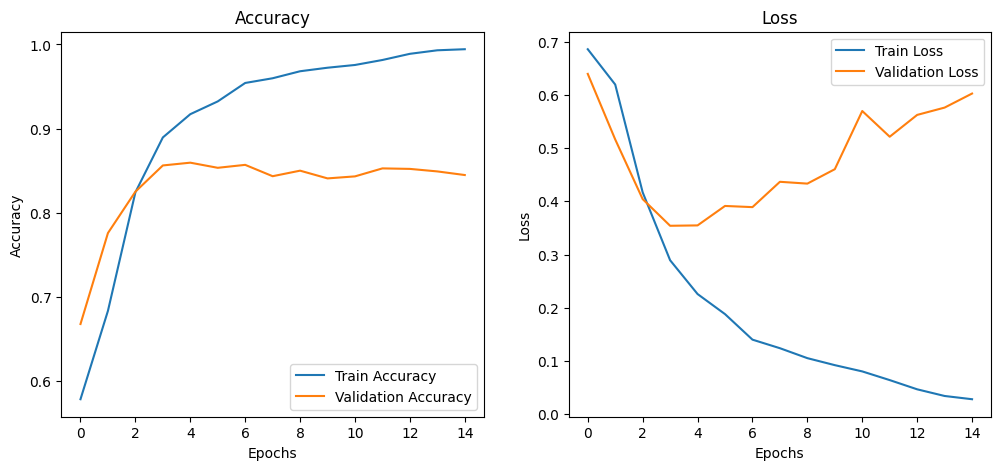

In [ ]:
#Visualization of the model
plt.figure(figsize=(12,5))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.show()